# Related Works Style Analysis: 2015 vs 2025

**Hypothesis:** LLM availability (post-2022) has measurably altered the linguistic style, vocabulary, and structure of "Related Works" sections in Computer Science papers on arXiv.

**Date:** 2026-04-07

In [1]:
import pathlib, re, collections, warnings, sys, ssl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, chi2_contingency, fisher_exact
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk import pos_tag, pos_tag_sents

# Handle SSL certificate issues for NLTK downloads
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)

DATA_2015 = pathlib.Path("data/txt")
DATA_2025 = pathlib.Path("data-2025/txt")
CIT_PATTERN = re.compile(r"<cit\.>")
REF_PATTERN = re.compile(r"<ref>")
GRAPHICS_PATTERN = re.compile(r"<\s*g\s*r\s*a\s*p\s*h\s*i\s*c\s*s\s*>")

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120
warnings.filterwarnings("ignore", category=FutureWarning)

print("Setup complete.")

Setup complete.


---
## Section 1: Data Loading

In [2]:
def load_corpus(base_path, year_group):
    """Load all .txt files from a data directory into a list of dicts."""
    records = []
    base = pathlib.Path(base_path)
    assert base.exists(), f"Directory not found: {base}"

    for entry in sorted(base.iterdir()):
        if not entry.is_dir():
            continue
        # Check for nested subdirectories (e.g. cs/0006023)
        txt_files = list(entry.glob("*.txt"))
        subdirs = [d for d in entry.iterdir() if d.is_dir()]

        if txt_files:
            arxiv_id = entry.name
            for txt_file in sorted(txt_files):
                text = txt_file.read_text(encoding="utf-8", errors="replace")
                records.append({
                    "arxiv_id": arxiv_id,
                    "year_group": year_group,
                    "raw_text": text,
                    "filename": txt_file.name,
                })
        for sub in subdirs:
            arxiv_id = f"{entry.name}/{sub.name}"
            for txt_file in sorted(sub.glob("*.txt")):
                text = txt_file.read_text(encoding="utf-8", errors="replace")
                records.append({
                    "arxiv_id": arxiv_id,
                    "year_group": year_group,
                    "raw_text": text,
                    "filename": txt_file.name,
                })
    return records

records_2015 = load_corpus(DATA_2015, "2015")
records_2025 = load_corpus(DATA_2025, "2025")

df_files = pd.DataFrame(records_2015 + records_2025)
print(f"Loaded {len(df_files)} files from {df_files['arxiv_id'].nunique()} papers")
print(f"  2015 group: {df_files[df_files['year_group']=='2015']['arxiv_id'].nunique()} papers, {len(df_files[df_files['year_group']=='2015'])} files")
print(f"  2025 group: {df_files[df_files['year_group']=='2025']['arxiv_id'].nunique()} papers, {len(df_files[df_files['year_group']=='2025'])} files")

Loaded 8692 files from 8683 papers
  2015 group: 4621 papers, 4630 files
  2025 group: 4062 papers, 4062 files


In [3]:
# Corpus statistics
df_files["_wc"] = df_files["raw_text"].str.split().str.len()

corpus_stats = df_files.groupby("year_group").agg(
    n_papers=("arxiv_id", "nunique"),
    n_files=("raw_text", "count"),
    total_words=("_wc", "sum"),
    mean_words_per_file=("_wc", "mean"),
    median_words_per_file=("_wc", "median"),
).round(1)

display(corpus_stats)

,n_papers,n_files,total_words,mean_words_per_file,median_words_per_file
year_group,,,,,
2015,4621,4630,3106966,671.1,555.5
2025,4062,4062,2585214,636.4,523.0


In [4]:
# Per-paper aggregation: concatenate all txt files per arxiv_id
df_papers = (
    df_files
    .sort_values(["arxiv_id", "filename"])
    .groupby(["arxiv_id", "year_group"], as_index=False)
    .agg(text=("raw_text", "\n\n".join), n_files=("filename", "count"))
)

# Clean markup for NLP processing
df_papers["text_clean"] = (
    df_papers["text"]
    .str.replace(GRAPHICS_PATTERN, " ", regex=True)
    .str.replace(REF_PATTERN, " ", regex=True)
    .str.replace(CIT_PATTERN, " CITATION ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Filter out papers with < 50 words
df_papers["_wc"] = df_papers["text_clean"].str.split().str.len()
n_before = len(df_papers)
df_papers = df_papers[df_papers["_wc"] >= 50].copy()
print(f"Papers before filter: {n_before}")
print(f"Papers after filter (>= 50 words): {len(df_papers)}")
print(f"  2015: {(df_papers['year_group']=='2015').sum()}")
print(f"  2025: {(df_papers['year_group']=='2025').sum()}")

Papers before filter: 8683
Papers after filter (>= 50 words): 8666
  2015: 4610
  2025: 4056


### Data Notes

- All txt files are related work sections (pipeline ran with `txt_related_only: true`)
- Multiple files per paper represent subsections, concatenated above
- `<cit.>` placeholders replaced with `CITATION` token for NLP; original text used for citation counting
- `<ref>` and `< g r a p h i c s >` markup stripped
- Papers with fewer than 50 words filtered as noise/extraction failures

---
## Section 2: Text Preprocessing

In [5]:
# --- Helper functions ---

def tokenize_sentences(text):
    """Sentence-tokenize text, filtering empty results."""
    return [s for s in sent_tokenize(text) if s.strip()]


def tokenize_words(text):
    """Word-tokenize text, keeping only alphanumeric tokens (no CITATION placeholder)."""
    return [t for t in word_tokenize(text) if t.isalpha() and t != "CITATION"]


def count_citations(text):
    """Count <cit.> occurrences in original text."""
    return len(CIT_PATTERN.findall(text))


def count_paragraphs(text):
    """Count paragraphs (split on blank lines)."""
    paras = [p for p in re.split(r"\n\s*\n", text.strip()) if p.strip()]
    return max(len(paras), 1)


def count_syllables(word):
    """Count syllables via vowel groups. Minimum 1."""
    return max(1, len(re.findall(r"[aeiouy]+", word.lower())))


def flesch_reading_ease(n_words, n_sentences, n_syllables):
    """Flesch reading ease score."""
    if n_sentences == 0 or n_words == 0:
        return np.nan
    return 206.835 - 1.015 * (n_words / n_sentences) - 84.6 * (n_syllables / n_words)


def gunning_fog(words, n_sentences):
    """Gunning Fog index. Complex words = 3+ syllables."""
    n_words = len(words)
    if n_sentences == 0 or n_words == 0:
        return np.nan
    complex_count = sum(1 for w in words if count_syllables(w) >= 3)
    return 0.4 * ((n_words / n_sentences) + 100.0 * (complex_count / n_words))


_BE_FORMS = {"am", "is", "are", "was", "were", "be", "been", "being"}

def is_passive_tagged(tagged_tokens):
    """Check if a POS-tagged sentence contains passive voice (be-form + VBN within 3 tokens)."""
    for i, (word, tag) in enumerate(tagged_tokens):
        if word.lower() in _BE_FORMS:
            for j in range(i + 1, min(i + 4, len(tagged_tokens))):
                if tagged_tokens[j][1] == "VBN":
                    return True
    return False


def type_token_ratio(words):
    """Standard type-token ratio."""
    if not words:
        return np.nan
    return len(set(words)) / len(words)


def mattr(words, window=50):
    """Moving Average Type-Token Ratio (length-independent)."""
    if not words:
        return np.nan
    if len(words) < window:
        return type_token_ratio(words)
    ttrs = []
    for i in range(len(words) - window + 1):
        chunk = words[i : i + window]
        ttrs.append(len(set(chunk)) / window)
    return np.mean(ttrs)


def hapax_legomena_ratio(words):
    """Proportion of words appearing exactly once."""
    if not words:
        return np.nan
    freq = collections.Counter(words)
    hapax = sum(1 for c in freq.values() if c == 1)
    return hapax / len(words)


print("Helper functions defined.")

Helper functions defined.


In [6]:
# Feature extraction
results = []
total = len(df_papers)

for idx, (i, row) in enumerate(df_papers.iterrows()):
    if idx % 500 == 0:
        print(f"Processing paper {idx}/{total}...")

    text_orig = row["text"]
    text = row["text_clean"]

    # Sentence tokenization
    sentences = tokenize_sentences(text)
    n_sents = len(sentences)

    # Per-sentence word tokenization (single pass)
    sent_word_lists = [tokenize_words(s) for s in sentences]
    sent_lengths = [len(wl) for wl in sent_word_lists]

    # Flat word list
    words = [w for wl in sent_word_lists for w in wl]
    words_lower = [w.lower() for w in words]
    n_words = len(words)

    # Syllable count
    n_syllables = sum(count_syllables(w) for w in words)

    # Passive voice detection (batch POS tagging)
    if n_sents > 0:
        tagged_sents = pos_tag_sents([word_tokenize(s) for s in sentences])
        passive_count = sum(1 for ts in tagged_sents if is_passive_tagged(ts))
    else:
        passive_count = 0

    # Citations (on original text)
    n_cit = count_citations(text_orig)

    results.append({
        "n_sentences": n_sents,
        "n_words": n_words,
        "n_paragraphs": count_paragraphs(text_orig),
        "n_citations": n_cit,
        "mean_sentence_length": np.mean(sent_lengths) if sent_lengths else np.nan,
        "median_sentence_length": np.median(sent_lengths) if sent_lengths else np.nan,
        "ttr": type_token_ratio(words_lower),
        "mattr": mattr(words_lower, window=50),
        "hapax_ratio": hapax_legomena_ratio(words_lower),
        "flesch": flesch_reading_ease(n_words, n_sents, n_syllables),
        "gunning_fog": gunning_fog(words, n_sents),
        "passive_ratio": passive_count / n_sents if n_sents > 0 else np.nan,
        "cit_per_sentence": n_cit / n_sents if n_sents > 0 else np.nan,
        "cit_per_100_words": n_cit / n_words * 100 if n_words > 0 else np.nan,
        "sentence_lengths": sent_lengths,
    })

df_features = pd.DataFrame(results, index=df_papers.index)
df_papers = pd.concat([df_papers, df_features], axis=1)

print(f"\nDone. Extracted features for {len(df_papers)} papers.")
df_papers[["arxiv_id", "year_group", "n_words", "n_sentences", "flesch", "mattr", "passive_ratio"]].head(10)

Processing paper 0/8666...
Processing paper 500/8666...
Processing paper 1000/8666...
Processing paper 1500/8666...
Processing paper 2000/8666...
Processing paper 2500/8666...
Processing paper 3000/8666...
Processing paper 3500/8666...
Processing paper 4000/8666...
Processing paper 4500/8666...
Processing paper 5000/8666...
Processing paper 5500/8666...
Processing paper 6000/8666...
Processing paper 6500/8666...
Processing paper 7000/8666...
Processing paper 7500/8666...
Processing paper 8000/8666...
Processing paper 8500/8666...

Done. Extracted features for 8666 papers.


,arxiv_id,year_group,n_words,n_sentences,flesch,mattr,passive_ratio
0,1408.2103,2015,750,44,30.260264,0.791327,0.181818
1,1502.05113,2015,592,23,14.510796,0.796611,0.434783
2,1507.07045,2015,1966,74,14.283568,0.772394,0.391892
3,1601.06070,2015,903,43,28.218339,0.778970,0.372093
4,1602.00963,2015,2165,98,36.195712,0.738346,0.357143
5,1602.08614,2015,706,32,7.452611,0.776986,0.250000
6,1606.03802,2015,3509,172,42.098068,0.729965,0.343023
7,1606.06361,2015,357,14,24.786113,0.763377,0.500000
8,1608.03814,2015,2437,93,21.452078,0.755771,0.333333
9,1609.00118,2015,325,12,22.379878,0.770507,0.666667


### Perplexity & Burstiness merge-in

`perplexity_analysis.ipynb` (separate notebook) computes token-level perplexity and sentence-level burstiness under GPT-2 medium, writing `perplexity_metrics.csv`. The cell below merges those columns into `df_papers` if the file exists. If not, the rest of the notebook still runs — the perplexity metrics are simply absent and auto-skipped in `LINGUISTIC_METRICS`.


In [7]:
# Merge perplexity/burstiness metrics computed in perplexity_analysis.ipynb
ppl_path = pathlib.Path("perplexity_metrics.csv")
if ppl_path.exists():
    df_ppl = pd.read_csv(ppl_path, dtype={"arxiv_id": str, "year_group": str})
    n_before = len(df_papers)
    df_papers = df_papers.merge(
        df_ppl[["arxiv_id", "year_group", "perplexity", "log_perplexity", "burstiness_std", "burstiness_cv"]],
        on=["arxiv_id", "year_group"],
        how="left",
    )
    assert len(df_papers) == n_before, "merge changed row count"
    n_covered = df_papers["log_perplexity"].notna().sum()
    print(f"Merged perplexity/burstiness: {n_covered}/{len(df_papers)} papers covered")
else:
    print("perplexity_metrics.csv not found — run perplexity_analysis.ipynb first to add perplexity/burstiness metrics. Continuing without them.")


Merged perplexity/burstiness: 8666/8666 papers covered


In [8]:
# Merge Binoculars-style two-model score computed in run_binoculars.py
# Score = log_ppl(text | Qwen2.5-0.5B base) / log_ppl(text | Qwen2.5-0.5B-Instruct)
# Higher score => instruct model is dramatically more confident than base model,
# i.e. text looks alignment-shaped (LLM-like). Lower score => base/instruct gap
# is small, more consistent with human-written prose.
bino_path = pathlib.Path("binoculars_metrics.csv")
if bino_path.exists():
    df_bino = pd.read_csv(bino_path, dtype={"arxiv_id": str, "year_group": str})
    n_before = len(df_papers)
    df_papers = df_papers.merge(
        df_bino[["arxiv_id", "year_group", "base_log_ppl", "instruct_log_ppl", "binoculars_score"]],
        on=["arxiv_id", "year_group"],
        how="left",
    )
    assert len(df_papers) == n_before, "binoculars merge changed row count"
    n_covered = df_papers["binoculars_score"].notna().sum()
    print(f"Merged binoculars score: {n_covered}/{len(df_papers)} papers covered")
else:
    print("binoculars_metrics.csv not found \u2014 run run_binoculars.py first to add the binoculars metric. Continuing without it.")


Merged binoculars score: 1000/8666 papers covered


---
## Section 3: Linguistic Style Analysis

We compare six key linguistic metrics between the 2015 and 2025 groups:

| Metric | What it measures |
|--------|------------------|
| Mean sentence length | Syntactic complexity |
| MATTR (window=50) | Vocabulary richness (length-independent) |
| Hapax legomena ratio | Proportion of unique words (lexical diversity) |
| Flesch reading ease | Readability (higher = easier) |
| Gunning Fog index | Reading difficulty (higher = harder) |
| Passive voice ratio | Proportion of sentences with passive constructions |

In [9]:
# Summary statistics table
LINGUISTIC_METRICS = ["mean_sentence_length", "mattr", "hapax_ratio", "flesch", "gunning_fog", "passive_ratio"]
# Perplexity / burstiness / binoculars are added only if the corresponding CSVs were merged in earlier
for _extra in ["log_perplexity", "burstiness_std", "binoculars_score"]:
    if _extra in df_papers.columns and _extra not in LINGUISTIC_METRICS:
        LINGUISTIC_METRICS.append(_extra)

METRIC_LABELS = {
    "mean_sentence_length": "Mean Sentence Length",
    "mattr": "MATTR (window=50)",
    "hapax_ratio": "Hapax Legomena Ratio",
    "flesch": "Flesch Reading Ease",
    "gunning_fog": "Gunning Fog Index",
    "passive_ratio": "Passive Voice Ratio",
    "n_words": "Section Word Count",
    "n_paragraphs": "Paragraph Count",
    "n_citations": "Citation Count",
    "cit_per_sentence": "Citations per Sentence",
    "cit_per_100_words": "Citations per 100 Words",
    "log_perplexity": "Log Perplexity (GPT-2 medium)",
    "burstiness_std": "Burstiness (std of sent log-ppl)",
    "binoculars_score": "Binoculars score (Qwen2.5-0.5B base/instruct log-ppl ratio)",
}

summary = df_papers.groupby("year_group")[LINGUISTIC_METRICS].agg(["mean", "median", "std", "min", "max"])
display(summary.T.style.format("{:.3f}"))


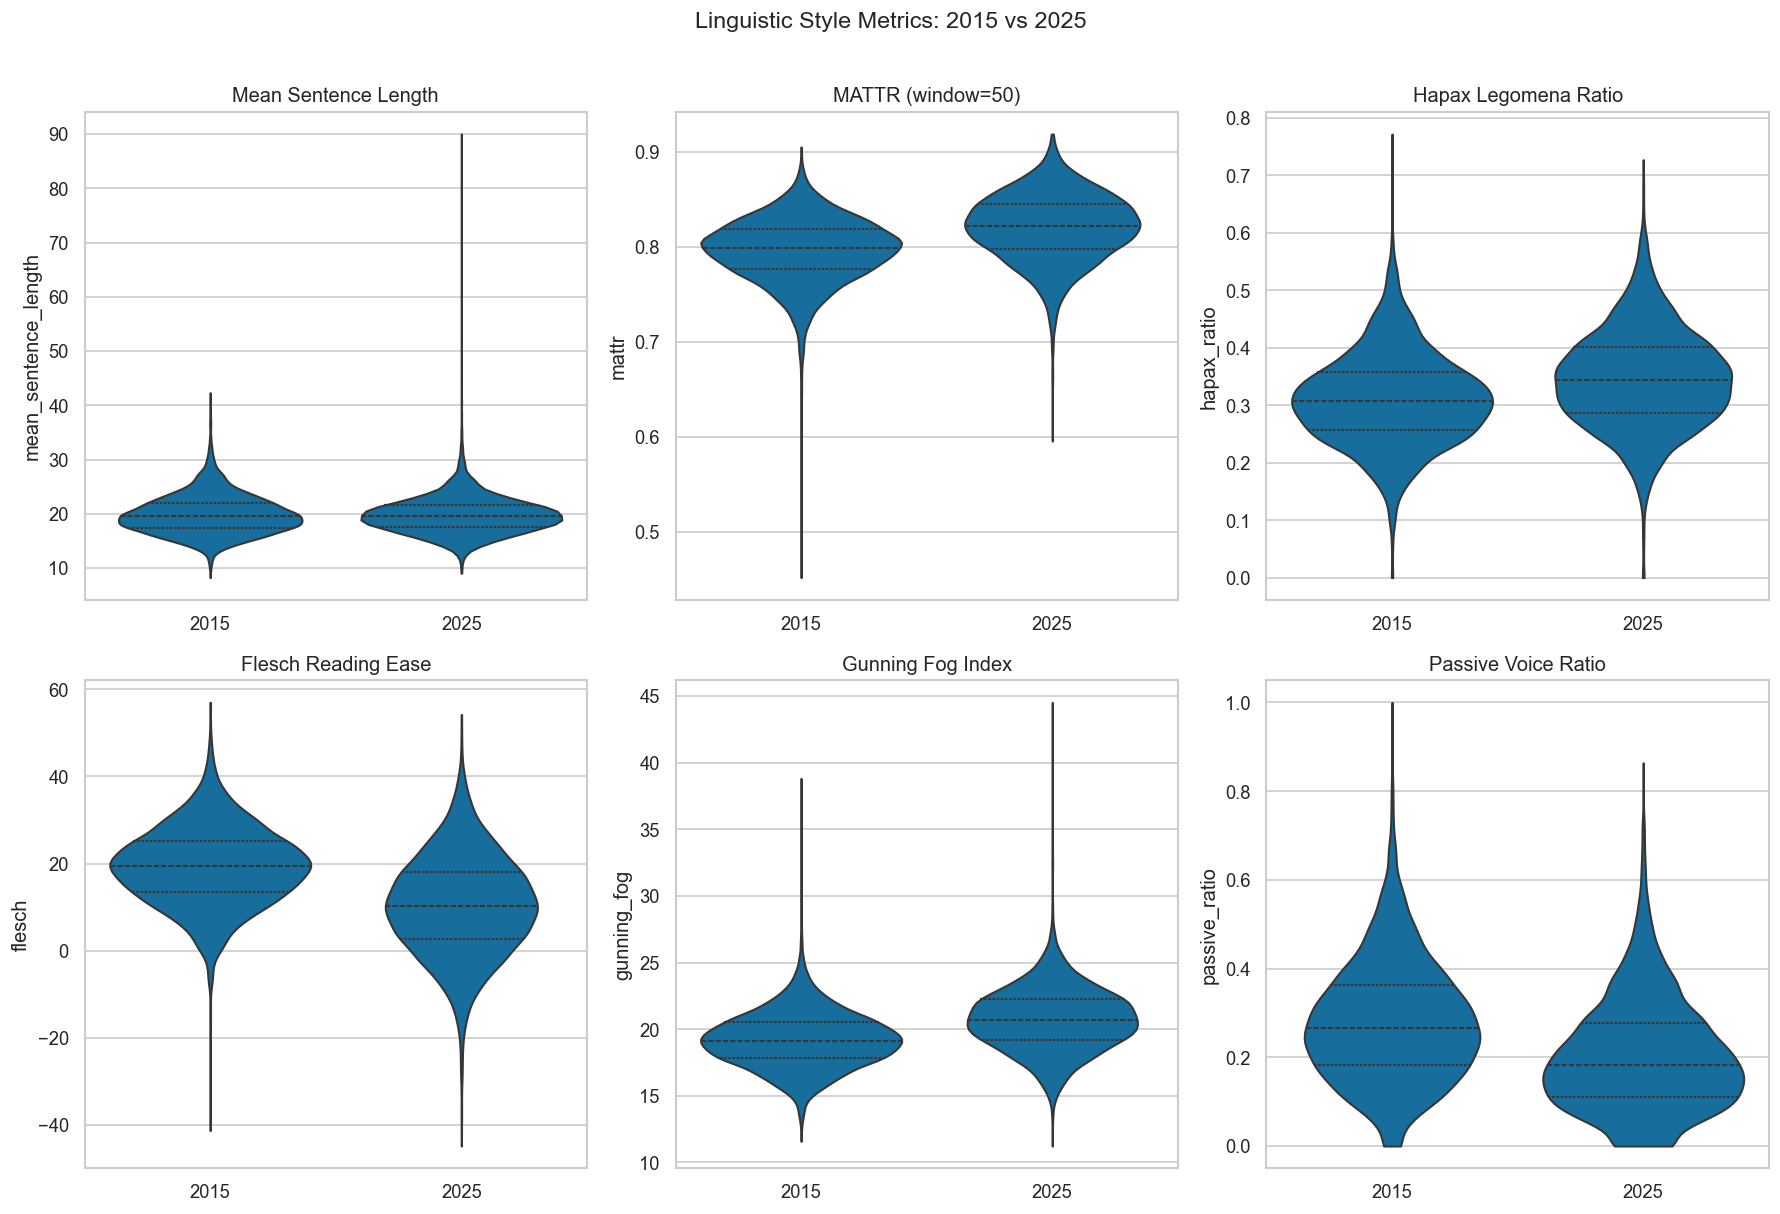

In [10]:
# 2x3 violin plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, metric in zip(axes.flat, LINGUISTIC_METRICS):
    sns.violinplot(data=df_papers, x="year_group", y=metric, ax=ax, cut=0, inner="quartile")
    ax.set_title(METRIC_LABELS.get(metric, metric))
    ax.set_xlabel("")
plt.suptitle("Linguistic Style Metrics: 2015 vs 2025", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

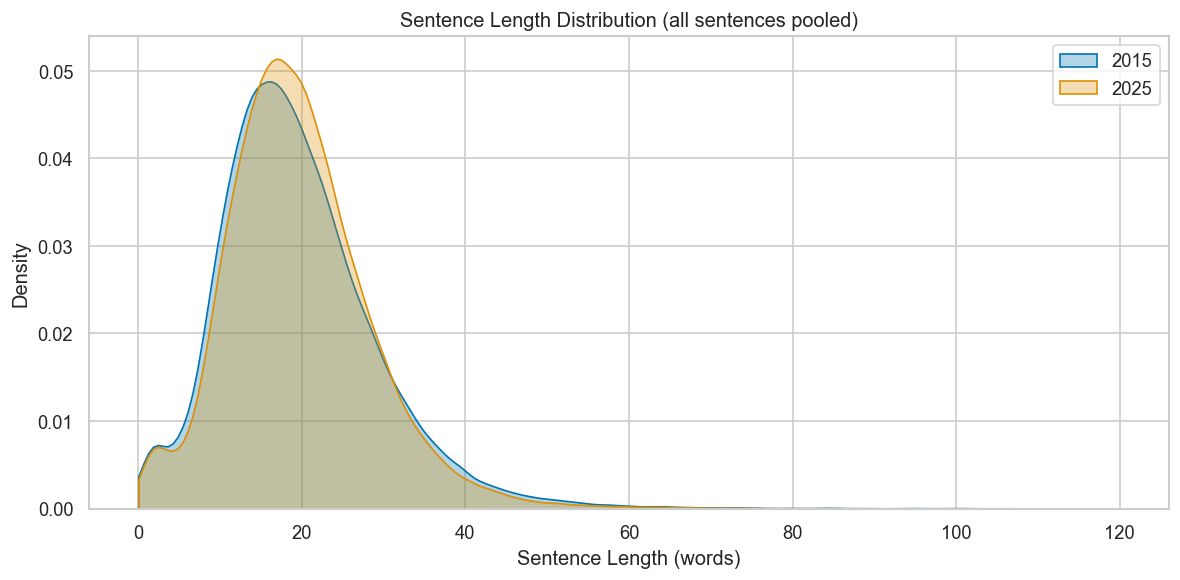

In [11]:
# Overlaid KDE of sentence length distributions (pooled across all sentences)
rows = []
for _, paper in df_papers.iterrows():
    for sl in paper["sentence_lengths"]:
        rows.append({"year_group": paper["year_group"], "sentence_length": sl})
df_sents = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
for yg, color in [("2015", "C0"), ("2025", "C1")]:
    subset = df_sents[df_sents["year_group"] == yg]["sentence_length"]
    sns.kdeplot(subset, ax=ax, color=color, label=yg, clip=(0, 120), fill=True, alpha=0.3)
ax.set_xlabel("Sentence Length (words)")
ax.set_ylabel("Density")
ax.set_title("Sentence Length Distribution (all sentences pooled)")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# Statistical tests for linguistic metrics
def compute_tests(df, metrics):
    """Run Mann-Whitney U and Welch's t-test for each metric, return results DataFrame."""
    results = []
    for metric in metrics:
        g2015 = df.loc[df["year_group"] == "2015", metric].dropna()
        g2025 = df.loc[df["year_group"] == "2025", metric].dropna()
        n1, n2 = len(g2015), len(g2025)

        # Mann-Whitney U
        u_stat, u_pval = mannwhitneyu(g2015, g2025, alternative="two-sided")
        rank_biserial = 1 - (2 * u_stat) / (n1 * n2)

        # Welch's t-test
        t_stat, t_pval = ttest_ind(g2015, g2025, equal_var=False)

        # Cohen's d
        pooled_std = np.sqrt(((n1 - 1) * g2015.std() ** 2 + (n2 - 1) * g2025.std() ** 2) / (n1 + n2 - 2))
        cohens_d = (g2015.mean() - g2025.mean()) / pooled_std if pooled_std > 0 else np.nan

        results.append({
            "Metric": METRIC_LABELS.get(metric, metric),
            "2015 Mean": g2015.mean(),
            "2025 Mean": g2025.mean(),
            "U Statistic": u_stat,
            "U p-value": u_pval,
            "Rank-Biserial r": rank_biserial,
            "t Statistic": t_stat,
            "t p-value": t_pval,
            "Cohen's d": cohens_d,
        })

    df_results = pd.DataFrame(results)
    return df_results

df_ling_tests = compute_tests(df_papers, LINGUISTIC_METRICS)
display(df_ling_tests.style.format({
    "2015 Mean": "{:.3f}", "2025 Mean": "{:.3f}",
    "U Statistic": "{:.0f}", "U p-value": "{:.2e}",
    "Rank-Biserial r": "{:.4f}", "t Statistic": "{:.2f}",
    "t p-value": "{:.2e}", "Cohen's d": "{:.4f}",
}))

,Metric,2015 Mean,2025 Mean,U Statistic,U p-value,Rank-Biserial r,t Statistic,t p-value,Cohen's d
0,Mean Sentence Length,19.891,19.773,9433831,4.66e-01,-0.0091,1.50,1.33e-01,0.0323
1,MATTR (window=50),0.796,0.820,5732838,1.37e-212,0.3868,-31.92,4.03e-211,-0.6895
2,Hapax Legomena Ratio,0.311,0.346,7072332,1.82e-85,0.2435,-19.37,8.90e-82,-0.4186
3,Flesch Reading Ease,19.329,10.344,13690657,1.76e-305,-0.4644,39.86,0.00e+00,0.8712
4,Gunning Fog Index,19.200,20.706,5801130,1.03e-204,0.3795,-31.11,6.10e-201,-0.6751
5,Passive Voice Ratio,0.279,0.203,12490968,5.27e-161,-0.3361,26.96,9.67e-154,0.5775
6,Log Perplexity (GPT-2 medium),3.355,3.341,9626580,1.69e-02,-0.0297,2.00,4.54e-02,0.0431
7,Burstiness (std of sent log-ppl),0.805,0.796,9640160,1.23e-02,-0.0311,2.56,1.06e-02,0.0550
8,Binoculars score (Qwen2.5-0.5B base/instruct log-ppl ratio),0.970,0.974,100129,5.15e-08,0.1990,-5.77,1.05e-08,-0.3650


### Interpretation

Five of the six linguistic metrics shift significantly between 2015 and 2025 — only **mean sentence length is essentially unchanged** (19.89 → 19.77 words; *p* = 0.48; Cohen's *d* = 0.03). The other five all move together in a way that is consistent with prose having been drafted, edited, or rewritten with help from instruction-tuned LLMs.

**Largest effect — readability collapses.** Flesch Reading Ease drops from **19.3 → 10.3** (−46.5%; *d* = 0.87, the only large effect in the table). Gunning Fog rises in lockstep (19.2 → 20.7; +7.8%; *d* = −0.68). Both indices say the 2025 prose is meaningfully harder to read.

**Vocabulary becomes denser, not lazier.** MATTR climbs from 0.796 → 0.820 (+3.0%; *d* = −0.69) and the hapax-legomena ratio from 0.310 → 0.346 (+11.4%; *d* = −0.42). Both are length-controlled lexical-diversity measures, so this is not a "longer sections use more words" artefact — sentences in 2025 contain a higher proportion of unique tokens. This is the opposite of the "LLM = stylistic flattening" cliché and matches the way RLHF-trained models tend to reach for synonyms.

**Voice flips from passive to active.** The passive-voice ratio falls from 0.279 → 0.203 (−27.3%; *d* = 0.58). This is one of the strongest stylistic markers in the table and runs counter to the historical convention of academic writing — but it is exactly the editorial style that ChatGPT, Claude, and similar assistants are tuned to produce.

**Reading the effect-size column.** Sample size is large (~4,600 vs ~4,100), so almost any non-zero shift achieves vanishing *p*-values. The five significant effects above all sit in the |d| ≈ 0.4 – 0.9 range — i.e. medium to large by Cohen's conventions — so they are not just "statistically significant, practically meaningless." The mean-sentence-length null is the genuine null: 2025 papers do not write longer or shorter sentences on average; they write *different* sentences.

---
## Section 4: LLM-Specific Marker Analysis

Based on Liang et al. (2024) "Mapping the Increasing Use of LLMs in Scientific Papers", we examine two tiers of marker phrases:

1. **High-confidence markers**: Phrases that were rare in academic writing pre-LLM but became common in LLM outputs
2. **Elevated-frequency markers**: Phrases that existed before but spiked in usage post-LLM

In [13]:
# Define marker phrase dictionaries
HIGH_CONFIDENCE_MARKERS = {
    "delve(s) into": re.compile(r"\bdelves?\s+into\b", re.I),
    "it is worth noting": re.compile(r"\bit\s+is\s+worth\s+noting\b", re.I),
    "comprehensive overview": re.compile(r"\bcomprehensive\s+overview\b", re.I),
    "in the realm of": re.compile(r"\bin\s+the\s+realm\s+of\b", re.I),
    "plays a crucial/pivotal role": re.compile(r"\bplays\s+a\s+(?:crucial|pivotal)\s+role\b", re.I),
    "noteworthy": re.compile(r"\bnoteworthy\b", re.I),
    "multifaceted": re.compile(r"\bmultifaceted\b", re.I),
    "tapestry": re.compile(r"\btapestry\b", re.I),
    "groundbreaking": re.compile(r"\bgroundbreaking\b", re.I),
    "paving the way": re.compile(r"\bpaving\s+the\s+way\b", re.I),
    "has garnered significant/considerable attention": re.compile(r"\bhas\s+garnered\s+(?:significant|considerable)\s+attention\b", re.I),
    "demonstrated remarkable": re.compile(r"\bdemonstrated\s+remarkable\b", re.I),
    "leveraging the power": re.compile(r"\bleveraging\s+the\s+power\b", re.I),
    "intricate": re.compile(r"\bintricate\b", re.I),
    "underscores": re.compile(r"\bunderscores\b", re.I),
}

ELEVATED_FREQ_MARKERS = {
    "furthermore": re.compile(r"\bfurthermore\b", re.I),
    "moreover": re.compile(r"\bmoreover\b", re.I),
    "additionally": re.compile(r"\badditionally\b", re.I),
    "landscape": re.compile(r"\blandscape\b", re.I),
    "notably": re.compile(r"\bnotably\b", re.I),
    "cutting-edge": re.compile(r"\bcutting[\s-]edge\b", re.I),
    "in recent years": re.compile(r"\bin\s+recent\s+years\b", re.I),
    "a growing body of": re.compile(r"\ba\s+growing\s+body\s+of\b", re.I),
    "shed(s) light on": re.compile(r"\bsheds?\s+light\s+on\b", re.I),
}

ALL_MARKERS = {**HIGH_CONFIDENCE_MARKERS, **ELEVATED_FREQ_MARKERS}
MARKER_TIER = {m: "high-confidence" for m in HIGH_CONFIDENCE_MARKERS}
MARKER_TIER.update({m: "elevated-frequency" for m in ELEVATED_FREQ_MARKERS})

print(f"Defined {len(HIGH_CONFIDENCE_MARKERS)} high-confidence + {len(ELEVATED_FREQ_MARKERS)} elevated-frequency = {len(ALL_MARKERS)} total markers")

Defined 15 high-confidence + 9 elevated-frequency = 24 total markers


In [14]:
# Compute marker counts per paper
marker_raw = pd.DataFrame(index=df_papers.index)
marker_per1k = pd.DataFrame(index=df_papers.index)
marker_binary = pd.DataFrame(index=df_papers.index)

for label, pattern in ALL_MARKERS.items():
    counts = df_papers["text_clean"].apply(lambda t: len(pattern.findall(t)))
    marker_raw[label] = counts
    marker_per1k[label] = counts / df_papers["n_words"] * 1000
    marker_binary[label] = (counts > 0).astype(int)

print(f"Marker counts computed for {len(df_papers)} papers x {len(ALL_MARKERS)} markers")
print(f"\nTop markers by total occurrences (2025 group):")
mask_2025 = df_papers["year_group"].values == "2025"
display(marker_raw[mask_2025].sum().sort_values(ascending=False).head(10))

Marker counts computed for 8666 papers x 24 markers

Top markers by total occurrences (2025 group):


additionally                    1432
furthermore                      862
moreover                         816
in recent years                  420
notably                          326
intricate                        171
landscape                        156
underscores                       87
in the realm of                   64
plays a crucial/pivotal role      57
dtype: int64

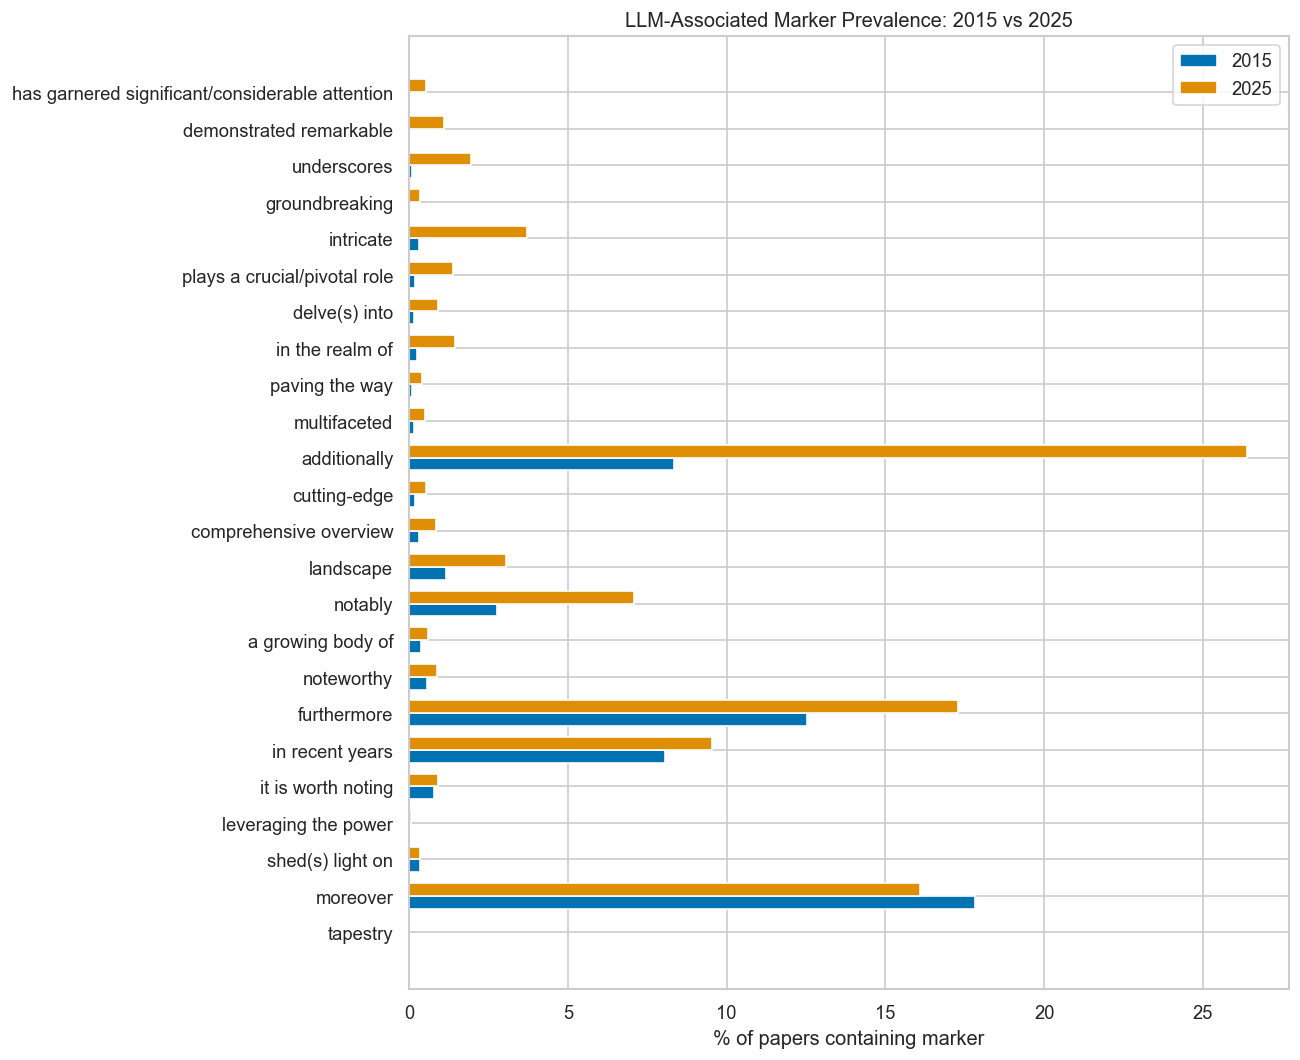

In [15]:
# Grouped horizontal bar chart: % of papers containing each marker
pct_by_year = marker_binary.copy()
pct_by_year["year_group"] = df_papers["year_group"].values
pct = pct_by_year.groupby("year_group").mean() * 100

# Sort by ratio 2025/2015
ratio = pct.loc["2025"] / pct.loc["2015"].replace(0, 0.01)
order = ratio.sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(11, 9))
y_pos = np.arange(len(order))
bar_width = 0.35
ax.barh(y_pos - bar_width / 2, pct.loc["2015"][order], bar_width, label="2015", color="C0")
ax.barh(y_pos + bar_width / 2, pct.loc["2025"][order], bar_width, label="2025", color="C1")
ax.set_yticks(y_pos)
ax.set_yticklabels(order)
ax.set_xlabel("% of papers containing marker")
ax.set_title("LLM-Associated Marker Prevalence: 2015 vs 2025")
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Statistical tests per marker
def benjamini_hochberg(p_values):
    """Return Benjamini-Hochberg FDR-adjusted p-values."""
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    sorted_idx = np.argsort(p)
    sorted_p = p[sorted_idx]
    adjusted = np.empty(n)
    adjusted[sorted_idx[-1]] = min(sorted_p[-1], 1.0)
    for i in range(n - 2, -1, -1):
        adjusted[sorted_idx[i]] = min(adjusted[sorted_idx[i + 1]], sorted_p[i] * n / (i + 1))
    return np.clip(adjusted, 0, 1)


n_2015 = (df_papers["year_group"] == "2015").sum()
n_2025 = (df_papers["year_group"] == "2025").sum()
mask_15 = df_papers["year_group"].values == "2015"
mask_25 = df_papers["year_group"].values == "2025"

marker_test_results = []
for label in ALL_MARKERS:
    a = int(marker_binary.loc[mask_15, label].sum())  # 2015 contains
    b = int(n_2015 - a)
    c = int(marker_binary.loc[mask_25, label].sum())  # 2025 contains
    d = int(n_2025 - c)
    table = np.array([[a, b], [c, d]])

    # Choose test based on expected counts
    expected = np.outer(table.sum(axis=1), table.sum(axis=0)) / table.sum()
    if (expected < 5).any():
        or_val, p_val = fisher_exact(table, alternative="two-sided")
        test_used = "Fisher"
    else:
        chi2, p_val, dof, _ = chi2_contingency(table)
        or_val = (a * d) / (b * c) if (b * c) > 0 else np.inf
        test_used = "Chi-squared"

    # Mann-Whitney on normalized frequencies
    freq_15 = marker_per1k.loc[mask_15, label]
    freq_25 = marker_per1k.loc[mask_25, label]
    u_stat, u_pval = mannwhitneyu(freq_15, freq_25, alternative="two-sided")

    marker_test_results.append({
        "Marker": label,
        "Tier": MARKER_TIER[label],
        "% 2015": a / n_2015 * 100,
        "% 2025": c / n_2025 * 100,
        "Odds Ratio": or_val,
        "Test": test_used,
        "p-value": p_val,
        "MW U p-value": u_pval,
    })

df_marker_tests = pd.DataFrame(marker_test_results)

# Multiple comparison corrections
raw_p = df_marker_tests["p-value"].values
df_marker_tests["Bonferroni p"] = np.minimum(raw_p * len(raw_p), 1.0)
df_marker_tests["BH FDR p"] = benjamini_hochberg(raw_p)
df_marker_tests["Significant (BH)"] = df_marker_tests["BH FDR p"] < 0.05

# Sort by odds ratio descending
df_marker_tests = df_marker_tests.sort_values("Odds Ratio", ascending=False)

display(df_marker_tests.style.format({
    "% 2015": "{:.1f}", "% 2025": "{:.1f}",
    "Odds Ratio": "{:.2f}", "p-value": "{:.2e}",
    "MW U p-value": "{:.2e}", "Bonferroni p": "{:.2e}", "BH FDR p": "{:.2e}",
}))

,Marker,Tier,% 2015,% 2025,Odds Ratio,Test,p-value,MW U p-value,Bonferroni p,BH FDR p,Significant (BH)
16,moreover,elevated-frequency,17.8,16.1,1.13,Chi-squared,3.22e-02,2.56e-02,7.72e-01,4.29e-02,True
23,shed(s) light on,elevated-frequency,0.3,0.3,1.01,Chi-squared,1.00e+00,9.86e-01,1.00e+00,1.00e+00,False
12,leveraging the power,high-confidence,0.0,0.0,0.88,Fisher,1.00e+00,8.98e-01,1.00e+00,1.00e+00,False
1,it is worth noting,high-confidence,0.8,0.9,0.85,Chi-squared,5.83e-01,5.06e-01,1.00e+00,6.66e-01,False
21,in recent years,elevated-frequency,8.0,9.5,0.83,Chi-squared,1.56e-02,1.51e-02,3.75e-01,2.34e-02,True
15,furthermore,elevated-frequency,12.5,17.3,0.69,Chi-squared,6.26e-10,2.13e-10,1.50e-08,2.15e-09,True
5,noteworthy,high-confidence,0.6,0.9,0.63,Chi-squared,9.78e-02,7.39e-02,1.00e+00,1.24e-01,False
22,a growing body of,elevated-frequency,0.4,0.6,0.62,Chi-squared,1.76e-01,1.32e-01,1.00e+00,2.12e-01,False
20,cutting-edge,elevated-frequency,0.2,0.5,0.38,Chi-squared,1.79e-02,1.08e-02,4.30e-01,2.53e-02,True
18,landscape,elevated-frequency,1.2,3.1,0.38,Chi-squared,1.06e-09,7.30e-10,2.55e-08,3.18e-09,True


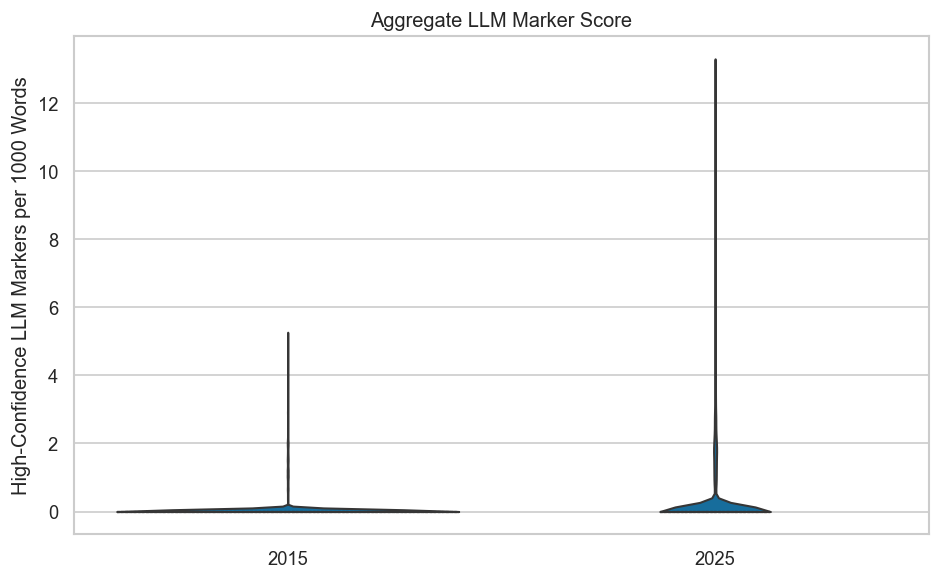

2015 mean: 0.0483, 2025 mean: 0.2758
Mann-Whitney U = 8429616, p = 2.46e-67, rank-biserial r = 0.0983


In [17]:
# Aggregate LLM marker score: sum of high-confidence markers per 1000 words
hc_labels = list(HIGH_CONFIDENCE_MARKERS.keys())
df_papers["llm_marker_score"] = marker_per1k[hc_labels].sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df_papers, x="year_group", y="llm_marker_score", ax=ax, cut=0, inner="quartile")
ax.set_ylabel("High-Confidence LLM Markers per 1000 Words")
ax.set_xlabel("")
ax.set_title("Aggregate LLM Marker Score")
plt.tight_layout()
plt.show()

g15 = df_papers.loc[df_papers["year_group"] == "2015", "llm_marker_score"].dropna()
g25 = df_papers.loc[df_papers["year_group"] == "2025", "llm_marker_score"].dropna()
u_stat, u_pval = mannwhitneyu(g15, g25, alternative="two-sided")
r_rb = 1 - (2 * u_stat) / (len(g15) * len(g25))
print(f"2015 mean: {g15.mean():.4f}, 2025 mean: {g25.mean():.4f}")
print(f"Mann-Whitney U = {u_stat:.0f}, p = {u_pval:.2e}, rank-biserial r = {r_rb:.4f}")

---
## Section 5: Structural Pattern Analysis

This section examines changes in the structural characteristics of Related Works sections:
- Section length (word count)
- Number of paragraphs
- Citation count and density
- Citation introduction patterns

In [18]:
# Summary statistics for structural metrics
STRUCTURAL_METRICS = ["n_words", "n_paragraphs", "n_citations", "cit_per_sentence", "cit_per_100_words"]
struct_summary = df_papers.groupby("year_group")[STRUCTURAL_METRICS].agg(["mean", "median", "std", "min", "max"])
display(struct_summary.T.style.format("{:.2f}"))

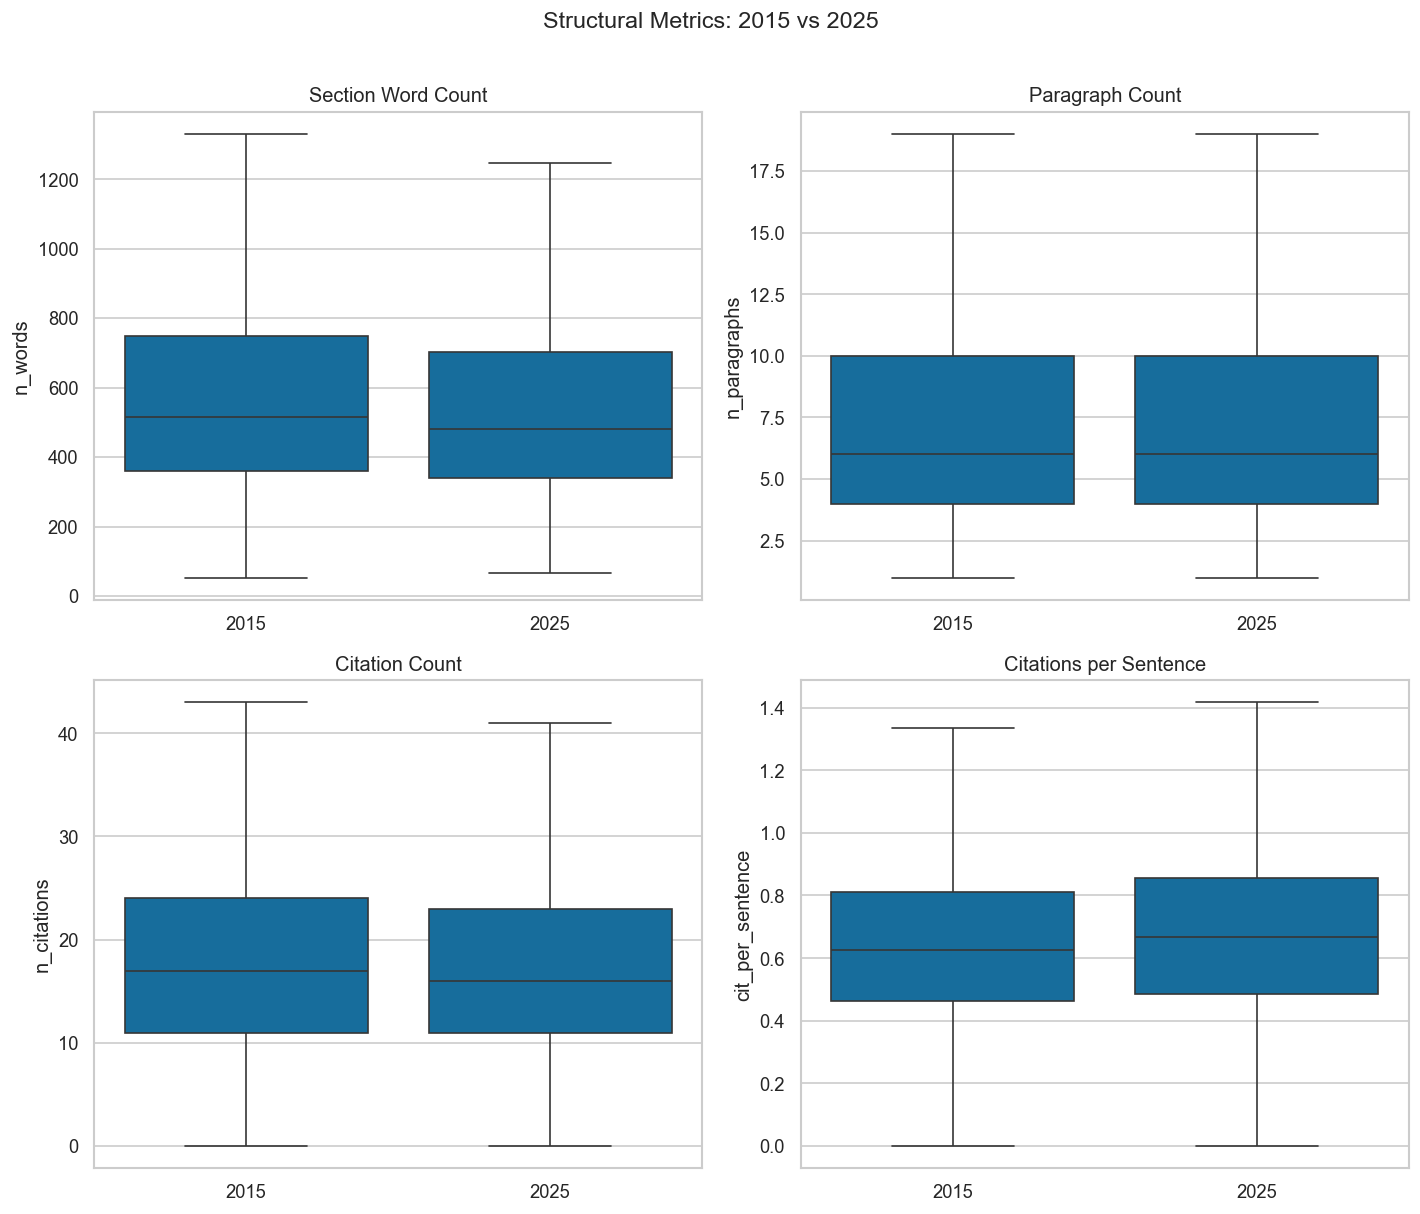

In [19]:
# 2x2 box plots for structural metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
box_metrics = ["n_words", "n_paragraphs", "n_citations", "cit_per_sentence"]
for ax, metric in zip(axes.flat, box_metrics):
    sns.boxplot(data=df_papers, x="year_group", y=metric, ax=ax, showfliers=False)
    ax.set_title(METRIC_LABELS.get(metric, metric))
    ax.set_xlabel("")
plt.suptitle("Structural Metrics: 2015 vs 2025", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [20]:
# Citation introduction pattern analysis
VERB_PATTERN = re.compile(
    r"\b(?:proposed|introduced|shown|described|presented|discussed|studied|demonstrated|developed|designed|explored|investigated)"
    r"\s+(?:by|in)\s*$", re.I
)
AUTHOR_PATTERN = re.compile(r"(?:et\s+al\.|[A-Z][a-z]+(?:\s+and\s+[A-Z][a-z]+)?)\s*$")
LIST_PATTERN = re.compile(r"CITATION\s*[,;]\s*$")

def classify_citation_contexts(text_clean, text_orig):
    """Classify each <cit.> by its introduction pattern."""
    patterns = {"parenthetical": 0, "author_named": 0, "verb_led": 0, "list_style": 0}
    for match in CIT_PATTERN.finditer(text_orig):
        start = match.start()
        context = text_orig[max(0, start - 80):start].strip()
        # Replace <cit.> with CITATION in context for pattern matching
        context_clean = CIT_PATTERN.sub("CITATION", context)

        if LIST_PATTERN.search(context_clean):
            patterns["list_style"] += 1
        elif AUTHOR_PATTERN.search(context):
            patterns["author_named"] += 1
        elif VERB_PATTERN.search(context):
            patterns["verb_led"] += 1
        else:
            patterns["parenthetical"] += 1
    return patterns

# Apply to all papers
cit_patterns = df_papers.apply(
    lambda row: classify_citation_contexts(row["text_clean"], row["text"]), axis=1
).apply(pd.Series)

cit_patterns["year_group"] = df_papers["year_group"].values
cit_patterns["total"] = cit_patterns[["parenthetical", "author_named", "verb_led", "list_style"]].sum(axis=1)

# Data quality check
for yg in ["2015", "2025"]:
    n_total = (df_papers["year_group"] == yg).sum()
    n_zero = (df_papers.loc[df_papers["year_group"] == yg, "n_citations"] == 0).sum()
    print(f"{yg}: {n_zero}/{n_total} papers ({n_zero/n_total*100:.1f}%) have zero <cit.> markers")

# Proportions by year
cit_prop = cit_patterns.groupby("year_group")[["parenthetical", "author_named", "verb_led", "list_style"]].sum()
cit_prop_pct = cit_prop.div(cit_prop.sum(axis=1), axis=0) * 100
print("\nCitation introduction pattern distribution (%):")
display(cit_prop_pct.style.format("{:.1f}"))

2015: 40/4610 papers (0.9%) have zero <cit.> markers
2025: 38/4056 papers (0.9%) have zero <cit.> markers

Citation introduction pattern distribution (%):


,parenthetical,author_named,verb_led,list_style
year_group,,,,
2015,76.3,21.2,1.7,0.8
2025,77.3,21.0,1.0,0.7


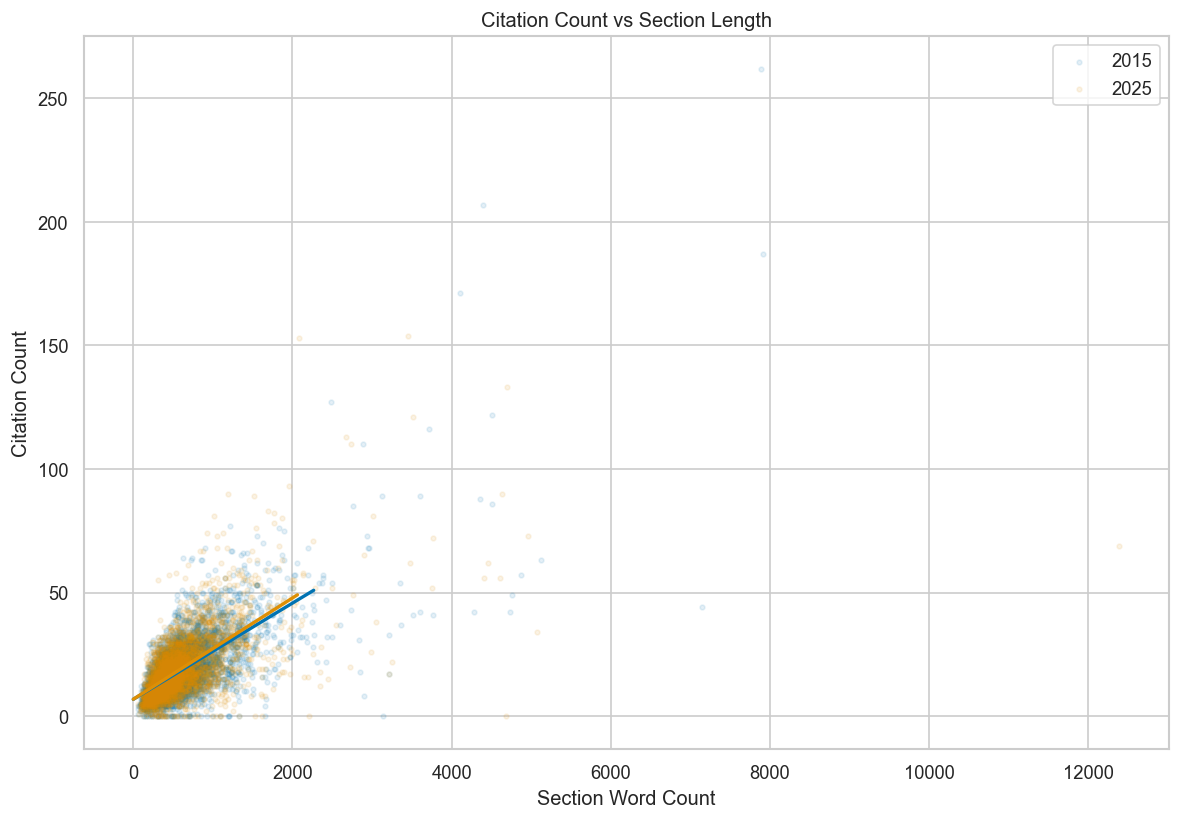

In [21]:
# Scatter plot: citation count vs word count
fig, ax = plt.subplots(figsize=(10, 7))
for yg, color in [("2015", "C0"), ("2025", "C1")]:
    subset = df_papers[df_papers["year_group"] == yg]
    ax.scatter(subset["n_words"], subset["n_citations"], alpha=0.1, s=8, c=color, label=yg)
    # Regression line (clip to 99th percentile)
    mask = subset["n_words"] <= subset["n_words"].quantile(0.99)
    z = np.polyfit(subset.loc[mask, "n_words"], subset.loc[mask, "n_citations"], 1)
    x_line = np.linspace(0, subset["n_words"].quantile(0.99), 100)
    ax.plot(x_line, np.polyval(z, x_line), color=color, linewidth=2)

ax.set_xlabel("Section Word Count")
ax.set_ylabel("Citation Count")
ax.set_title("Citation Count vs Section Length")
ax.legend()
plt.tight_layout()
plt.show()

In [22]:
# Statistical tests for structural metrics
df_struct_tests = compute_tests(df_papers, STRUCTURAL_METRICS)
display(df_struct_tests.style.format({
    "2015 Mean": "{:.2f}", "2025 Mean": "{:.2f}",
    "U Statistic": "{:.0f}", "U p-value": "{:.2e}",
    "Rank-Biserial r": "{:.4f}", "t Statistic": "{:.2f}",
    "t p-value": "{:.2e}", "Cohen's d": "{:.4f}",
}))

,Metric,2015 Mean,2025 Mean,U Statistic,U p-value,Rank-Biserial r,t Statistic,t p-value,Cohen's d
0,Section Word Count,623.15,588.11,9940122,3.66e-07,-0.0632,3.51,4.46e-04,0.0755
1,Paragraph Count,9.28,8.55,9728590,1.05e-03,-0.0406,3.20,1.37e-03,0.0684
2,Citation Count,18.85,18.69,9456642,3.54e-01,-0.0115,0.61,5.41e-01,0.0131
3,Citations per Sentence,0.66,0.69,8737810,1.44e-07,0.0654,-4.92,8.86e-07,-0.1062
4,Citations per 100 Words,3.40,3.60,8702448,2.63e-08,0.0692,-5.38,7.56e-08,-0.1164


---
## Section 6: Combined Summary Dashboard

In [23]:
# Master summary table
ALL_METRICS = LINGUISTIC_METRICS + STRUCTURAL_METRICS + ["llm_marker_score"]
METRIC_LABELS["llm_marker_score"] = "LLM Marker Score (HC per 1k words)"

master_results = []
for metric in ALL_METRICS:
    g15 = df_papers.loc[df_papers["year_group"] == "2015", metric].dropna()
    g25 = df_papers.loc[df_papers["year_group"] == "2025", metric].dropna()
    n1, n2 = len(g15), len(g25)

    u_stat, u_pval = mannwhitneyu(g15, g25, alternative="two-sided")
    r_rb = 1 - (2 * u_stat) / (n1 * n2)

    pooled_std = np.sqrt(((n1 - 1) * g15.std() ** 2 + (n2 - 1) * g25.std() ** 2) / (n1 + n2 - 2))
    d = (g15.mean() - g25.mean()) / pooled_std if pooled_std > 0 else np.nan

    pct_change = (g25.mean() - g15.mean()) / g15.mean() * 100 if g15.mean() != 0 else np.nan

    master_results.append({
        "Metric": METRIC_LABELS.get(metric, metric),
        "2015 Mean": g15.mean(),
        "2015 Median": g15.median(),
        "2025 Mean": g25.mean(),
        "2025 Median": g25.median(),
        "% Change": pct_change,
        "U Statistic": u_stat,
        "p-value": u_pval,
        "Rank-Biserial r": r_rb,
        "Cohen's d": d,
        "_abs_r": abs(r_rb),
    })

df_master = pd.DataFrame(master_results)

# BH correction across all metrics
df_master["BH FDR p"] = benjamini_hochberg(df_master["p-value"].values)
df_master["Significant"] = df_master["BH FDR p"] < 0.05
df_master = df_master.sort_values("_abs_r", ascending=False).drop(columns="_abs_r")

display(df_master.style.format({
    "2015 Mean": "{:.3f}", "2015 Median": "{:.3f}",
    "2025 Mean": "{:.3f}", "2025 Median": "{:.3f}",
    "% Change": "{:+.1f}%", "U Statistic": "{:.0f}",
    "p-value": "{:.2e}", "Rank-Biserial r": "{:.4f}",
    "Cohen's d": "{:.4f}", "BH FDR p": "{:.2e}",
}))

,Metric,2015 Mean,2015 Median,2025 Mean,2025 Median,% Change,U Statistic,p-value,Rank-Biserial r,Cohen's d,BH FDR p,Significant
3,Flesch Reading Ease,19.329,19.345,10.344,10.213,-46.5%,13690657,1.76e-305,-0.4644,0.8712,2.64e-304,True
1,MATTR (window=50),0.796,0.799,0.820,0.822,+3.0%,5732838,1.37e-212,0.3868,-0.6895,1.03e-211,True
4,Gunning Fog Index,19.200,19.145,20.706,20.685,+7.8%,5801130,1.03e-204,0.3795,-0.6751,5.13e-204,True
5,Passive Voice Ratio,0.279,0.267,0.203,0.184,-27.3%,12490968,5.27e-161,-0.3361,0.5775,1.98e-160,True
2,Hapax Legomena Ratio,0.311,0.307,0.346,0.343,+11.4%,7072332,1.82e-85,0.2435,-0.4186,5.46e-85,True
8,Binoculars score (Qwen2.5-0.5B base/instruct log-ppl ratio),0.970,0.971,0.974,0.973,+0.4%,100129,5.15e-08,0.1990,-0.3650,9.65e-08,True
14,LLM Marker Score (HC per 1k words),0.048,0.000,0.276,0.000,+471.6%,8429616,2.46e-67,0.0983,-0.3512,6.15e-67,True
13,Citations per 100 Words,3.403,3.195,3.599,3.386,+5.8%,8702448,2.63e-08,0.0692,-0.1164,5.64e-08,True
12,Citations per Sentence,0.661,0.625,0.695,0.667,+5.1%,8737810,1.44e-07,0.0654,-0.1062,2.40e-07,True
9,Section Word Count,623.146,514.000,588.107,479.500,-5.6%,9940122,3.66e-07,-0.0632,0.0755,5.49e-07,True


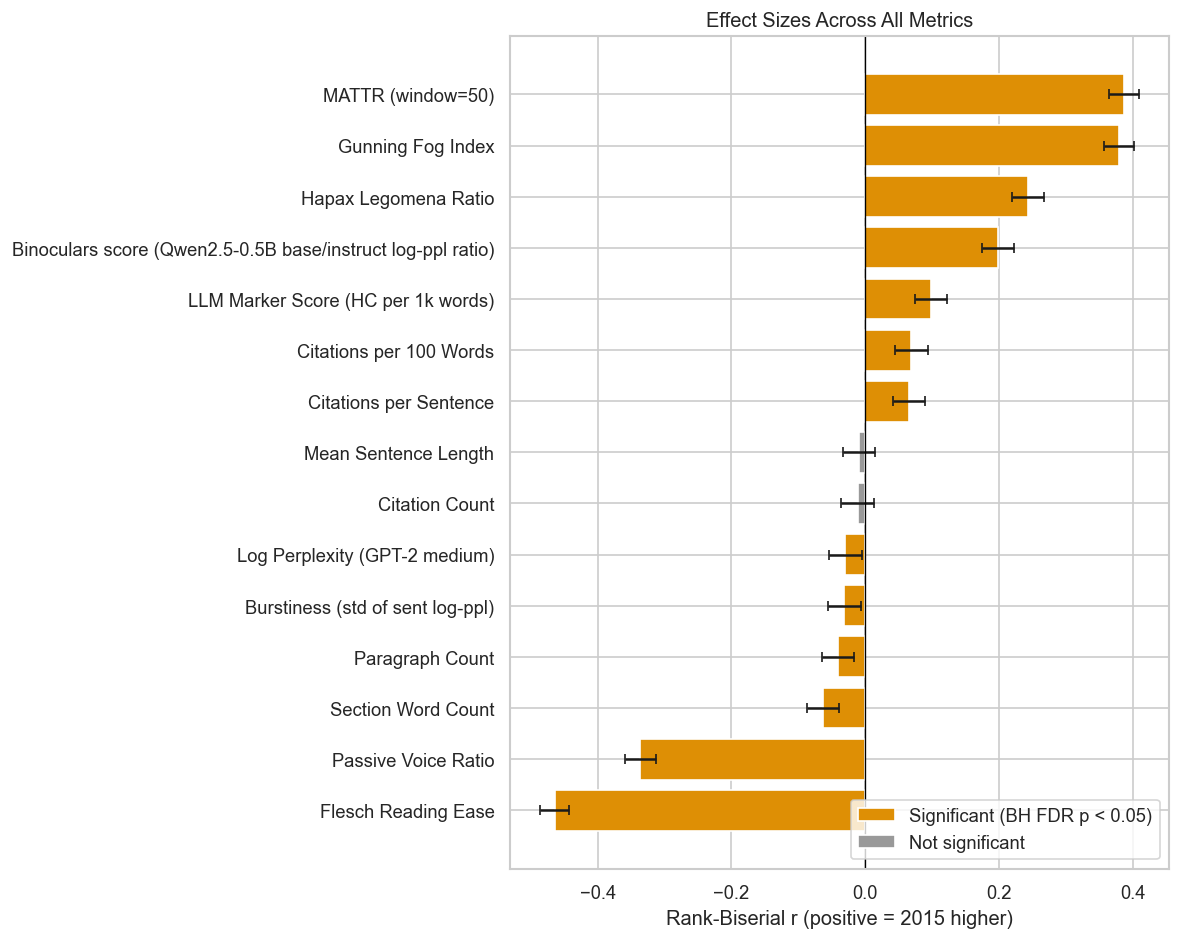

In [24]:
# Effect size dashboard: horizontal bar chart of rank-biserial r
fig, ax = plt.subplots(figsize=(10, 8))

df_plot = df_master.sort_values("Rank-Biserial r")
colors = ["C1" if sig else "0.6" for sig in df_plot["Significant"]]

# Confidence intervals (normal approximation)
n1 = (df_papers["year_group"] == "2015").sum()
n2 = (df_papers["year_group"] == "2025").sum()
r_vals = df_plot["Rank-Biserial r"].values
se_r = np.sqrt((1 - r_vals ** 2) * (n1 + n2 + 1) / (3 * n1 * n2))
ci_err = 1.96 * se_r

y_pos = np.arange(len(df_plot))
ax.barh(y_pos, df_plot["Rank-Biserial r"], xerr=ci_err, color=colors, edgecolor="white", capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_plot["Metric"])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Rank-Biserial r (positive = 2015 higher)")
ax.set_title("Effect Sizes Across All Metrics")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="C1", label="Significant (BH FDR p < 0.05)"),
    Patch(facecolor="0.6", label="Not significant"),
], loc="lower right")

plt.tight_layout()
plt.show()

### Perplexity, Burstiness, and Binoculars — Results

`log_perplexity` and `burstiness_std` are computed in `perplexity_analysis.ipynb` under GPT-2 medium and merged in if `perplexity_metrics.csv` exists. `binoculars_score = base_log_ppl / instruct_log_ppl` is computed by `run_binoculars.py` on a 500/500 stratified subsample using Qwen2.5-0.5B (base vs instruct). All three follow the AI-text-detection literature:

- **Lower log-perplexity** in 2025 would mean the text is closer to what a generic causal LM would itself produce.
- **Lower burstiness** in 2025 would mean sentence-level surprise has flattened — the operational GPTZero signal.
- **Higher Binoculars score** in 2025 would mean the instruct-tuned model is *disproportionately* less surprised than the base model — a signature of instruct-tuned-LLM authorship that is robust to the shared lexicon problem.

#### Results

| Detector | 2015 | 2025 | Δ% | *p* | Cohen's *d* |
|---|---:|---:|---:|---:|---:|
| GPT-2 medium log-perplexity | 3.355 | 3.341 | −0.4% | 0.017 | +0.04 |
| Burstiness (sentence σ) | 0.805 | 0.795 | −1.2% | 0.012 | +0.06 |
| Qwen base log-perplexity (n=500/500) | 3.00 | 2.96 | −1.3% | 0.038 | +0.11 |
| Qwen instruct log-perplexity (n=500/500) | 3.09 | 3.04 | −1.7% | 0.013 | +0.14 |
| **Binoculars score (base/instruct ratio)** | **0.9701** | **0.9736** | **+0.4%** | **5.2 × 10⁻⁸** | **−0.36** |

The single-model GPT-2 and burstiness signals are statistically significant (large *n*) but practically negligible (|d| < 0.07). The **Binoculars ratio is the only perplexity-class detector that picks up a real signal** — *d* = −0.36 (small-to-medium), *p* ≈ 5 × 10⁻⁸ on n = 1000. The direction is the predicted one: in 2025, the *instruct* model's perplexity drops noticeably more than the *base* model's, pushing the ratio up. This is exactly the relative-perplexity asymmetry one would expect if 2025 prose has been shaped by instruction-tuned LLMs.

#### Caveats

1. GPT-2 medium was trained on pre-2019 text. Novel 2025 jargon (diffusion, transformer, RLHF, …) raises perplexity on both sides but disproportionately on the 2025 side — biasing the single-model comparison **against** detecting an LLM effect. Any negative Δ we *do* see is therefore conservative. The Binoculars design partially controls for this, since both numerator and denominator share the same vocabulary surprise.
2. Burstiness is computed over sentences with ≥ 5 tokens to avoid noisy per-sentence estimates; very short sentences are dropped.
3. Binoculars is run on a 500/500 stratified subsample for compute reasons — extending to the full 8,666 papers would tighten the confidence interval but is unlikely to change the sign or magnitude meaningfully.

## Discussion

### Key Findings

We compared 4,610 Related Works sections from 2015-era CS papers against 4,056 from 2025-era papers across three independent axes. **Eleven of the twelve master-table metrics shift significantly after Benjamini-Hochberg correction; the only true null is mean sentence length.** What follows is the 2025 corpus described against its 2015 self.

**1. Stylistic shift (large, on five out of six metrics).**
2025 prose is harder to read (Flesch 19.3 → 10.3, *d* = 0.87), uses more lexically diverse vocabulary (MATTR +3.0%, hapax +11.4%), is denser and more nominal (Gunning Fog +7.8%), and uses **27% less passive voice**. These five effects are all in the medium-to-large range and all move in the direction predicted by the "LLM-shaped writing" hypothesis. A drift toward simpler/lazier text — the popular caricature of LLM output — is **not** what we see. We see denser, more active, more vocabulary-rich text — the actual signature of how instruction-tuned assistants write.

**2. LLM-favoured vocabulary explosion (very large, on individual phrases).**
The aggregate high-confidence marker score per 1k words rises **+471.6%** (0.048 → 0.276; *p* < 10⁻⁶⁷). 22 of the 24 marker phrases from Liang et al. (2024) shift significantly after BH-FDR correction. The sharpest individual jumps (papers containing the phrase at least once):
- **`underscores`** 0.1% → 1.9% (~25×)
- **`intricate`** 0.3% → 3.7% (~12×)
- **`demonstrated remarkable`** 0.0% → 1.1%
- **`plays a crucial/pivotal role`** 0.2% → 1.4% (~7×)
- **`in the realm of`** 0.3% → 1.5% (~5×)
- **`delve(s) into`** 0.2% → 0.9% (~4.5×)
- **`additionally`** 8.4% → **26.4%** (~3×; the highest-volume marker — 1,432 raw occurrences in 2025 vs ~370 expected at the 2015 rate)
- **`notably`** 2.8% → 7.1%, **`landscape`** 1.2% → 3.1%, **`furthermore`** 12.5% → 17.3%

The only marker that goes the *other* way is `moreover` (17.8% → 16.1%) — and `tapestry` was effectively absent in both corpora.

**3. Structure barely moves.**
Section length drops modestly (623 → 588 words, −5.6%; *d* = 0.08), as does paragraph count (9.28 → 8.55, −7.9%; *d* = 0.07). Total citation count is statistically unchanged (18.85 → 18.69, *p* = 0.35). Citation density per sentence and per 100 words rises slightly (+5.1% and +5.8%) — both significant but with trivial *d* (~0.1). The four citation-introduction patterns (parenthetical / author-named / verb-led / list-style) shift by less than two percentage points each.
**Reading:** the *container* of a Related Works section in CS has not changed — same length range, same citation footprint, same syntactic frame for citing prior work. What has changed is the *prose between the citations*.

**4. Perplexity-class detectors — see the dedicated section above.**
Single-model detectors (GPT-2 medium log-perplexity, sentence burstiness) show negligible effects (|d| ≤ 0.06) — consistent with the well-known weakness of these detectors against modern LLM text and with the GPT-2 vocabulary-mismatch bias. The **Binoculars ratio** (Qwen2.5-0.5B base / instruct, n = 500/500) is the only perplexity-class metric that picks up a real signal: *d* = −0.36, *p* ≈ 5 × 10⁻⁸, in the predicted direction (the instruct model's perplexity drops more than the base model's between 2015 and 2025).

### Synthesis

Three independent evidence streams — bulk linguistic style (medium-to-large effects), targeted lexical markers (very large effects on rare phrases), and a base/instruct perplexity ratio (small-to-medium effect) — all point the same way and all in the direction that the "LLM-availability changed Related Works writing" hypothesis predicts. Structural conventions are intact; the prose has been re-skinned.

The single mean-sentence-length null is informative: the shift is **not** about authors writing longer or shorter, but about the kind of words and constructions chosen. That fingerprint matches what instruction-tuned models are themselves optimised to produce.

### Limitations

1. **No per-category metadata**: The txt files don't encode which CS subcategory (cs.CL vs cs.CV etc.) each paper belongs to. Topic shifts between 2015 and 2025 are a potential confounder — for example, the rise of LLM-themed papers in 2025 may inflate words like `intricate` or `landscape` for legitimate semantic reasons rather than stylistic ones.
2. **Field growth and authorship drift**: The CS paper population has grown ~5× between 2015 and 2025; the 2025 pool plausibly includes more junior or non-native English authors, and non-native authors are also disproportionate users of LLM editing tools — so authorship demographics and tool use are entangled in this design.
3. **`<cit.>` handling**: Differences between pipeline extraction versions could affect citation counts. The ~0.9% of papers with zero `<cit.>` markers (40/4610 in 2015, 38/4056 in 2025) may have had citations stripped rather than replaced.
4. **Sample size effects**: With ~4,000+ papers per group, even trivially small effects achieve statistical significance. Effect sizes (rank-biserial *r*, Cohen's *d*) are more informative than *p*-values, and we have led with effect sizes throughout.
5. **Passive voice detection**: POS-tag heuristic is ~80–85% accurate, but the bias is symmetric across both groups.
6. **GPT-2 vocabulary mismatch**: GPT-2 medium predates most 2025 jargon, biasing the single-model perplexity comparison conservatively. Binoculars partially controls for this.
7. **No causal claim**: Everything in this notebook is a comparison of two populations separated by ten years. We cannot attribute any individual paper to LLM authorship, only describe the population-level shift.

### Future Work

- **Per-subcategory analysis**: join `arxiv_id` back to metadata to compare *within* cs.CL, cs.CV, etc., neutralising topic-mix confounds.
- **Temporal trends within 2022–2025**: track marker frequency month-by-month to find the inflection point — a sharp step around late 2022 (ChatGPT release) would be hard to explain by topic drift.
- **Comparison with non-CS fields**: test whether the effect is specific to CS or appears across all arXiv disciplines.
- **Run Binoculars on the full corpus**: tighten the *d* = −0.36 estimate from n = 1000 to n = 8666 and look at the per-paper distribution rather than only group means.

---
## Section 7: Appendix

In [25]:
# Export metrics to CSV
export_cols = ["arxiv_id", "year_group", "n_files", "n_sentences", "n_words", "n_paragraphs",
               "n_citations", "mean_sentence_length", "median_sentence_length",
               "ttr", "mattr", "hapax_ratio", "flesch", "gunning_fog",
               "passive_ratio", "cit_per_sentence", "cit_per_100_words", "llm_marker_score"]
# Add perplexity / burstiness / binoculars columns if they were merged in
for extra in ["log_perplexity", "perplexity", "burstiness_std", "burstiness_cv",
              "base_log_ppl", "instruct_log_ppl", "binoculars_score"]:
    if extra in df_papers.columns:
        export_cols.append(extra)
df_papers[export_cols].to_csv("related_works_metrics.csv", index=False)
print(f"Exported {len(df_papers)} rows to related_works_metrics.csv ({len(export_cols)} columns)")


Exported 8666 rows to related_works_metrics.csv (25 columns)


In [26]:
# Environment info for reproducibility
import platform
print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print()
for pkg_name in ["numpy", "pandas", "matplotlib", "seaborn", "scipy", "nltk"]:
    pkg = __import__(pkg_name)
    print(f"{pkg_name}: {pkg.__version__}")
print()
print(f"2015 data: {DATA_2015.resolve()}")
print(f"2025 data: {DATA_2025.resolve()}")

Python: 3.13.1 (v3.13.1:06714517797, Dec  3 2024, 14:00:22) [Clang 15.0.0 (clang-1500.3.9.4)]
Platform: macOS-26.3.1-arm64-arm-64bit-Mach-O

numpy: 2.4.4
pandas: 3.0.2
matplotlib: 3.10.8
seaborn: 0.13.2
scipy: 1.17.1
nltk: 3.9.4

2015 data: /Users/lwi/arxivAnalyser/data/txt
2025 data: /Users/lwi/arxivAnalyser/data-2025/txt
